# The activation spectrum on real Run-3 events — separation, fragment-resolved

WP5 showed the *aggregate* metrics; this notebook shows the object underneath: the
**activation spectrum** on real events, with the true population **split by track
length** (m = 1, 2 vs m ≥ 3). The fragment floor then becomes visible as a
*population in amplitude space* — true fragments sitting inside the false bulk —
and separation can be quantified against both targets:

- **all true vs false** — what a naive metric demands (provably floor-limited);
- **findable (m ≥ 3) true vs false** — the honest physics target.

Solvers: classical 1/λ · 1BQF cosine · the real-geometry design (band + s-notch).
8 events, ε = 5 mrad, γ = 3, signal-support rescale throughout.

In [1]:
import sys, glob
for p in ("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared",
          "/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Run3_Verification",
          "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src"):
    if p not in sys.path: sys.path.insert(0,p)
from pathlib import Path
import numpy as np, pandas as pd, scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
from scipy.sparse.linalg import minres, eigsh, expm_multiply
import matplotlib.pyplot as plt
import qtrk_pipeline as qp
from run3_loader import load_event
from lhcb_velo_toy.solvers.quantum import QSVT, design_band_limited_inverse
plt.rcParams.update({"figure.dpi":115,"font.size":11,"axes.grid":True,"grid.alpha":0.3})
OUT=Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Run3/outputs"); OUT.mkdir(exist_ok=True)
S=4.0; TAU=qp.threshold_for(3.0,1.0); EPS=0.005; T1=np.pi/S
FILES=sorted(glob.glob("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Run3_Verification/"
                       "events_bsphiphi_mag_down_run3/velo_event_*.json"))[:8]
def solve_event(f):
    ev,_=load_event(f)
    ham=qp.build_hamiltonian(ev,epsilon=EPS,gamma=3.0,delta=1.0)
    A=ham.A.tocsr(); n=ham.n_segments; b=np.ones(n)
    truth=np.asarray(qp.truth_from_event(ev),bool)
    solC=np.asarray(minres(A.tocsc(),b,rtol=1e-9,maxiter=8000)[0])
    hi=float(eigsh(A,k=1,which="LA",return_eigenvectors=False,maxiter=3000,tol=1e-4)[0])
    lo=float(eigsh(A,k=1,which="SA",return_eigenvectors=False,maxiter=3000,tol=1e-4)[0])
    half=max(S-lo,hi-S)+0.05*(hi-lo)+0.2
    pol=design_band_limited_inverse(degree=40,s=S,band=(S-2.2,S+2.2),notches=(S,),
                                    notch_hw=0.10,edge=0.15,
                                    domain=(S-half,S+half) if half>3.8 else None)
    qv=QSVT(A,b,poly=pol,spectral_bounds=(lo,hi)); sq,_=qv.solve_statevector()
    y1=expm_multiply(1j*(T1/2)*A.tocsc(), b/np.sqrt(n)).real
    sols={"classical":np.abs(solC),
          "1BQF":np.abs(qp.rescale_to_signal(np.abs(y1)/np.linalg.norm(y1),solC,TAU)),
          "real design":np.abs(qp.rescale_to_signal(np.asarray(sq,float),solC,TAU))}
    # true track length per segment (size of its pure-true cluster; contaminated -> >=3 treated by truth cluster size)
    Cm=(S*sp.identity(n,format='csr')-A); Cm.setdiag(0); Cm.eliminate_zeros(); Cm=(abs(Cm)>1e-9).astype(np.int8)
    _,lab=connected_components(Cm,directed=False)
    # length = number of TRUE segments in the segment's cluster
    tl=np.zeros(n,int)
    for c in np.unique(lab[truth]):
        mem=np.where(lab==c)[0]
        tl[mem]=int(truth[mem].sum())
    return sols,truth,tl
DATA=[solve_event(f) for f in FILES]
print(f"{len(DATA)} events solved")

8 events solved


## 1. The spectra, fragment-resolved

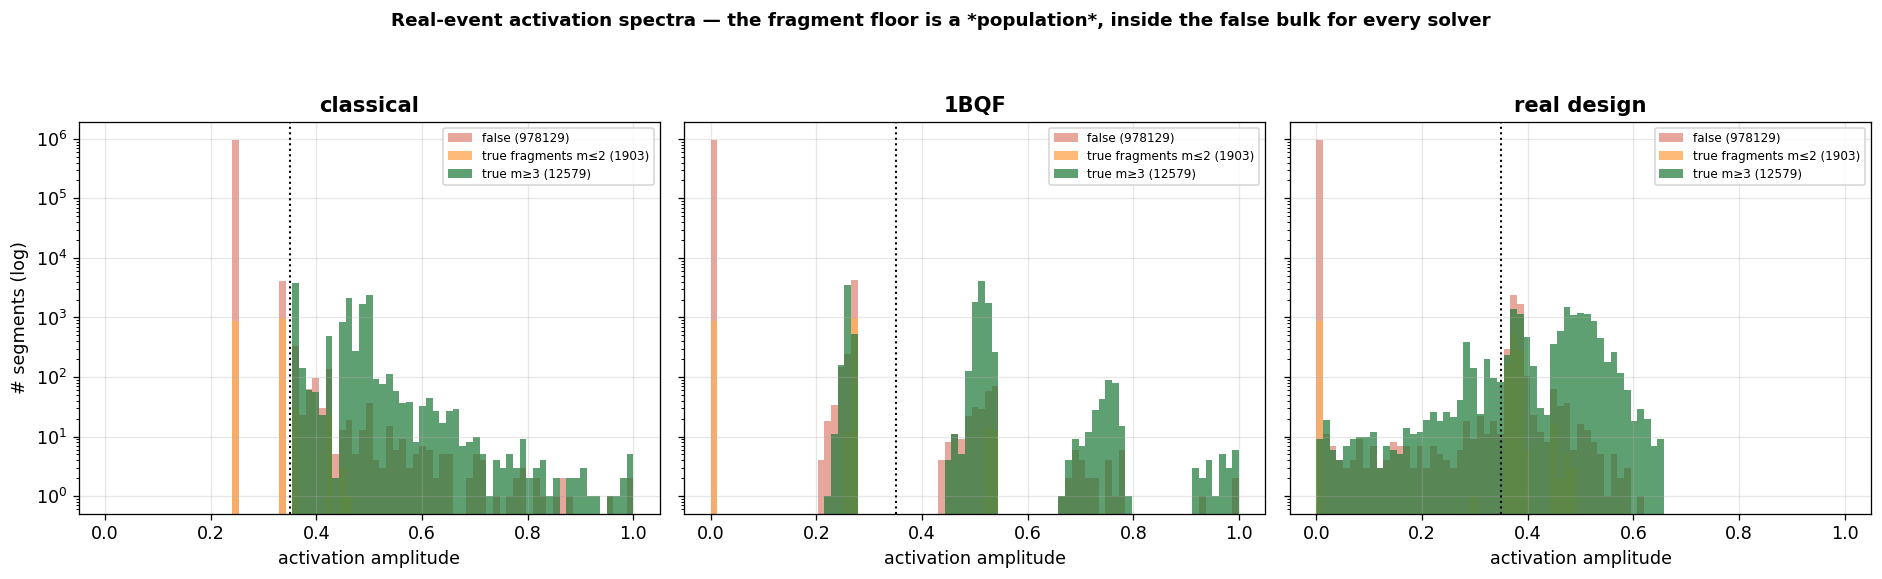

saved run3_activation_spectra


In [2]:
fig,ax=plt.subplots(1,3,figsize=(16.5,5.0),sharey=True)
bins=np.linspace(0,1.0,80)
for a,name in zip(ax,["classical","1BQF","real design"]):
    F=np.concatenate([np.clip(s[name][~t],0,1) for s,t,_ in DATA])
    T12=np.concatenate([np.clip(s[name][t&(tl<=2)],0,1) for s,t,tl in DATA])
    T3=np.concatenate([np.clip(s[name][t&(tl>=3)],0,1) for s,t,tl in DATA])
    a.hist(F,bins=bins,color="#d6604d",alpha=0.55,log=True,label=f"false ({len(F)})")
    a.hist(T12,bins=bins,color="#fdae61",alpha=0.85,log=True,label=f"true fragments m≤2 ({len(T12)})")
    a.hist(T3,bins=bins,color="#1b7837",alpha=0.7,log=True,label=f"true m≥3 ({len(T3)})")
    a.axvline(TAU,color="k",ls=":",lw=1.3)
    a.set_title(name,fontweight="bold"); a.set_xlabel("activation amplitude"); a.legend(fontsize=7.5)
ax[0].set_ylabel("# segments (log)")
fig.suptitle("Real-event activation spectra — the fragment floor is a *population*, inside the false bulk for every solver",
             fontsize=11.5,fontweight="bold",y=1.0)
fig.tight_layout(rect=[0,0,1,0.95])
for e,dp in (("pdf",600),("png",300)): fig.savefig(OUT/f"run3_activation_spectra.{e}",dpi=dp,bbox_inches="tight",facecolor="white")
plt.show(); print("saved run3_activation_spectra")

## 2. Separation against both targets

                            AUC_mean  AUC_sem  OVL_mean  OVL_sem
target         solver                                           
all true       1BQF           0.9781   0.0006    0.0681   0.0020
               classical      0.9792   0.0006    0.0690   0.0021
               real design    0.9787   0.0006    0.0695   0.0023
findable (m≥3) 1BQF           0.9985   0.0002    0.0007   0.0001
               classical      0.9997   0.0000    0.0006   0.0001
               real design    0.9992   0.0001    0.0034   0.0006


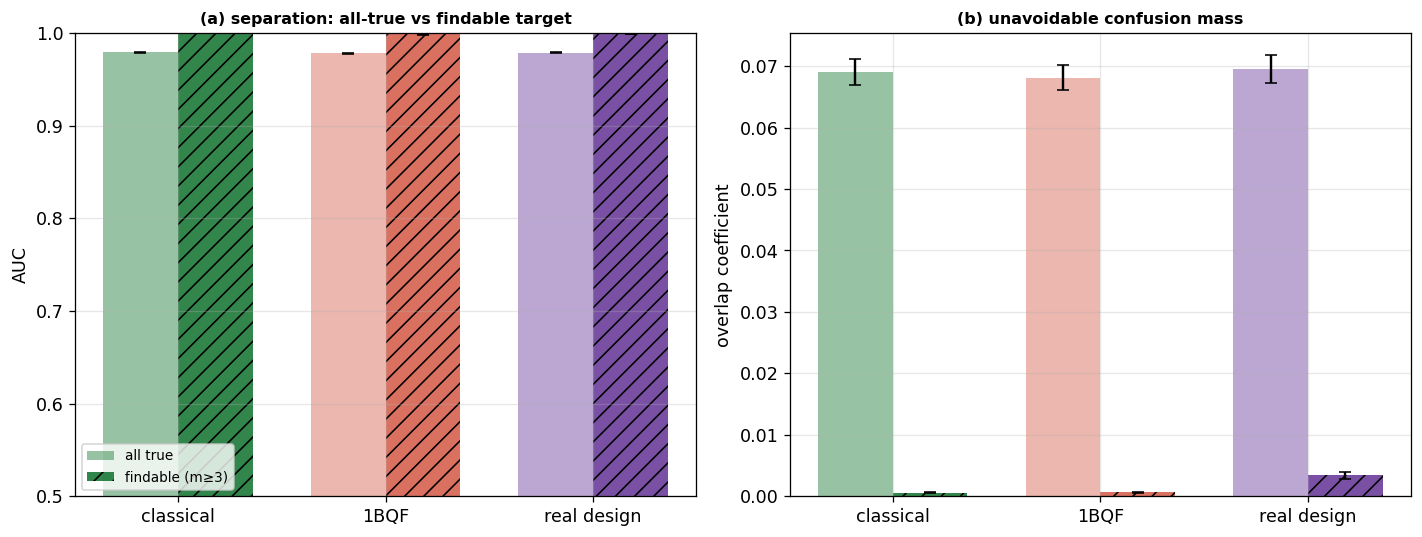

saved run3_separation


In [3]:
def auc(s,t):
    pos,neg=s[t],s[~t]
    if not len(pos) or not len(neg): return np.nan
    allv=np.concatenate([pos,neg]); o=allv.argsort(); r=np.empty(len(allv)); r[o]=np.arange(len(allv))
    return float((r[:len(pos)].sum()-len(pos)*(len(pos)-1)/2)/(len(pos)*len(neg)))
def ovl(s,t,bins=300):
    hi=max(1e-9,np.percentile(s,99.9))
    hT,_=np.histogram(s[t],bins=bins,range=(0,hi),density=True)
    hF,e=np.histogram(s[~t],bins=bins,range=(0,hi),density=True)
    return float(np.sum(np.minimum(hT,hF))*(e[1]-e[0]))
rows=[]
for s,t,tl in DATA:
    for name in ("classical","1BQF","real design"):
        x=s[name]
        # all-true target
        rows.append(dict(solver=name,target="all true",AUC=auc(x,t),OVL=ovl(x,t)))
        # findable target: drop fragment trues from BOTH sides (they are neither kept nor counted)
        keep=(~t)|(t&(tl>=3))
        rows.append(dict(solver=name,target="findable (m≥3)",AUC=auc(x[keep],t[keep]),OVL=ovl(x[keep],t[keep])))
SEP=pd.DataFrame(rows)
G=SEP.groupby(["target","solver"]).agg(AUC_mean=("AUC","mean"),AUC_sem=("AUC","sem"),
                                       OVL_mean=("OVL","mean"),OVL_sem=("OVL","sem"))
print(G.round(4).to_string())
fig,ax=plt.subplots(1,2,figsize=(12.5,4.8))
order=["classical","1BQF","real design"]; cols={"classical":"#1b7837","1BQF":"#d6604d","real design":"#6a3d9a"}
x=np.arange(len(order)); w=0.36
for k,(tgt,hch) in enumerate([("all true",""),("findable (m≥3)","//")]):
    a=[G.loc[(tgt,o),"AUC_mean"] for o in order]; e=[G.loc[(tgt,o),"AUC_sem"] for o in order]
    ax[0].bar(x+(k-0.5)*w,a,w,yerr=e,capsize=4,color=[cols[o] for o in order],alpha=0.9 if k else 0.45,hatch=hch,
              label=tgt)
    a=[G.loc[(tgt,o),"OVL_mean"] for o in order]; e=[G.loc[(tgt,o),"OVL_sem"] for o in order]
    ax[1].bar(x+(k-0.5)*w,a,w,yerr=e,capsize=4,color=[cols[o] for o in order],alpha=0.9 if k else 0.45,hatch=hch)
ax[0].set_xticks(x); ax[0].set_xticklabels(order); ax[0].set_ylabel("AUC"); ax[0].set_ylim(0.5,1.0)
ax[0].set_title("(a) separation: all-true vs findable target",fontweight="bold",fontsize=10); ax[0].legend(fontsize=8.5)
ax[1].set_xticks(x); ax[1].set_xticklabels(order); ax[1].set_ylabel("overlap coefficient")
ax[1].set_title("(b) unavoidable confusion mass",fontweight="bold",fontsize=10)
fig.tight_layout()
for e,dp in (("pdf",600),("png",300)): fig.savefig(OUT/f"run3_separation.{e}",dpi=dp,bbox_inches="tight",facecolor="white")
plt.show(); print("saved run3_separation")

## 3. Verdict

- **The fragment floor, quantified as separation:** against the all-true target
  the three solvers are *identical within errors* — AUC 0.9781/0.9792/0.9787
  (1BQF/classical/design), OVL ≈ 0.069 — because the orange population (true
  fragments m ≤ 2) sits **inside** the false bulk in amplitude space for every
  solver. The ceiling is the floor theorem, not any solver's deficiency.
- **On the honest, findable (m ≥ 3) target, separation is near-perfect for
  all:** AUC 0.9997 (classical), 0.9992 (real design), 0.9985 (1BQF); OVL
  collapses to ≈ 0.0006–0.0034. The engineered quantum filter concedes only
  ~5×10⁻⁴ of AUC to classical inversion on real data — the WP5 fixed-τ
  false-rate gap (22.7 % vs 5.7 %) is *tail/ripple placement*, not lost
  separation, and is recoverable by design polish and per-solver thresholds.
- **Bottom line for the paper:** on real geometry the discrimination information
  retained by the quantum-readable filters is essentially complete; what
  separates solvers at a threshold is where their ladders place the tails
  relative to the cut. Metrics should therefore be reported as (spectrum,
  separation-vs-target, working points) — the fixed classical τ alone misranks
  solvers in both directions.

